---
title: Ridge and LASSO Regularization
---

In the last lecture, we started discussing nonlinear regression models. As a motivating example, we considered the following dataset (from FRED) on Annual Estimates of the Resident Population of California (units are thousands of persons) from 1900 to 2024. 

In [132]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

  observation_date   CAPOP
0       1900-01-01  1490.0
1       1901-01-01  1550.0
2       1902-01-01  1623.0
3       1903-01-01  1702.0
4       1904-01-01  1792.0
5       1905-01-01  1893.0
6       1906-01-01  1976.0
7       1907-01-01  2054.0
8       1908-01-01  2161.0
9       1909-01-01  2282.0
    observation_date      CAPOP
116       2016-01-01  39149.186
117       2017-01-01  39337.785
118       2018-01-01  39437.463
119       2019-01-01  39437.610
120       2020-01-01  39527.808
121       2021-01-01  39152.927
122       2022-01-01  39125.347
123       2023-01-01  39181.667
124       2024-01-01  39364.774
125       2025-01-01  39355.309


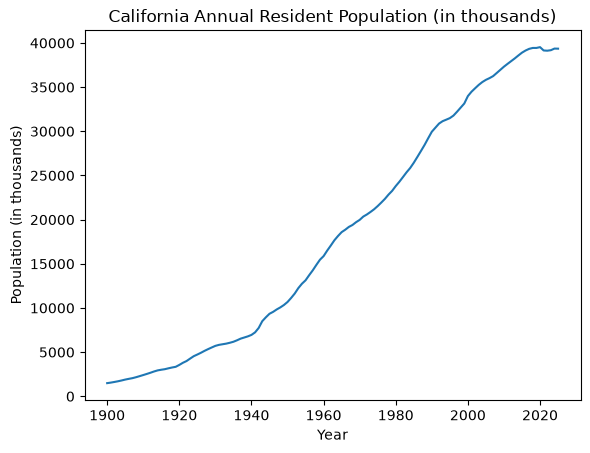

In [133]:
capop = pd.read_csv('CAPOP_29Sept2026.csv')
print(capop.head(10))
print(capop.tail(10))
tme = np.arange(1900, 2026)
plt.plot(tme, capop['CAPOP'], label='California Population')
plt.xlabel('Year')
plt.ylabel('Population (in thousands)')
plt.title('California Annual Resident Population (in thousands)')
plt.show()

We work with the logarithms of the population data as this will lead to models with better interpretability. 

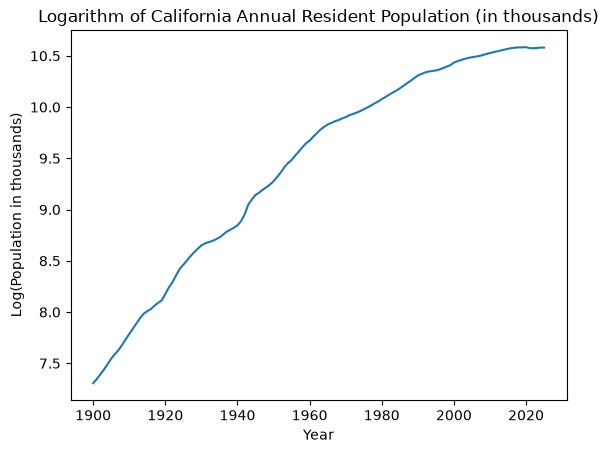

In [134]:
y = np.log(capop['CAPOP'])
n = len(y)
plt.plot(tme, y)
plt.xlabel('Year')
plt.ylabel('Log(Population in thousands)')
plt.title('Logarithm of California Annual Resident Population (in thousands)')
plt.show()

We shall fit the following model to this dataset:
\begin{equation*}
  y_t = \beta_0 + \beta_1 (t - 1) + \beta_2 (t - 2)_+ + \beta_3 (t - 3)_+ + \dots + \beta_{n-1} (t - (n-1))_+ + \epsilon_t
\end{equation*}
We can write this as
\begin{equation*}
   y = X_{\text{full}} \beta + \epsilon
\end{equation*}
where $X_{\text{full}}$ is constructed as below. 

In [135]:
n = len(y)
x = np.arange(1, n+1)
Xfull = np.column_stack([np.ones(n), x-1])
for i in range(n-2):
    c = i+2
    xc = ((x > c).astype(float))*(x-c)
    Xfull = np.column_stack([Xfull, xc])
print(Xfull)

[[  1.   0.  -0. ...  -0.  -0.  -0.]
 [  1.   1.   0. ...  -0.  -0.  -0.]
 [  1.   2.   1. ...  -0.  -0.  -0.]
 ...
 [  1. 123. 122. ...   1.   0.  -0.]
 [  1. 124. 123. ...   2.   1.   0.]
 [  1. 125. 124. ...   3.   2.   1.]]


If we fit this model without any regularization, we get the following. 

In [136]:
mdfull = sm.OLS(y, Xfull).fit()
print(mdfull.summary())

                            OLS Regression Results                            
Dep. Variable:                  CAPOP   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                    nan
Method:                 Least Squares   F-statistic:                       nan
Date:                Thu, 01 Oct 2026   Prob (F-statistic):                nan
Time:                        19:05:42   Log-Likelihood:                 3207.8
No. Observations:                 126   AIC:                            -6164.
Df Residuals:                       0   BIC:                            -5806.
Df Model:                         125                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          7.3065        inf          0        n

/Users/aditya/mambaforge/envs/stat153fall2026/lib/python3.14/site-packages/statsmodels/regression/linear_model.py:1795: RuntimeWarning: divide by zero encountered in divide
  return 1 - (np.divide(self.nobs - self.k_constant, self.df_resid)
/Users/aditya/mambaforge/envs/stat153fall2026/lib/python3.14/site-packages/statsmodels/regression/linear_model.py:1795: RuntimeWarning: invalid value encountered in scalar multiply
  return 1 - (np.divide(self.nobs - self.k_constant, self.df_resid)
/Users/aditya/mambaforge/envs/stat153fall2026/lib/python3.14/site-packages/statsmodels/regression/linear_model.py:1717: RuntimeWarning: divide by zero encountered in scalar divide
  return np.dot(wresid, wresid) / self.df_resid


In this unregularized estimation, the estimate of $\beta_0$ equals $y_1$, the estimate of $\beta_1$ is $y_2 - y_1$, and the estimate of $\beta_j$ is $y_{j+1} - 2 y_j + y_{j-1}$ for $j = 2, \dots, n-1$. Let us check this. 

In [137]:
print(y[0], mdfull.params.iloc[0])
print(y[1] - y[0], mdfull.params.iloc[1])
print(y[2] - y[1] - y[1] + y[0], mdfull.params.iloc[2])
print(y[3] - y[2] - y[2] + y[1], mdfull.params.iloc[3])
print(y[4] - y[3] - y[3] + y[2], mdfull.params.iloc[4])

7.306531398939505 7.306531398939486
0.03947881097378758 0.03947881097380328
0.006542546627510859 0.00654254662752654
0.0015063840174303067 0.0015063840174089499
0.004000542782827132 0.004000542782759602


## Ridge and LASSO regularized estimation

We now compute the ridge and lasso regularized estimators using the optimization library `cvxpy`. `cvxpy` is a library for formulating and solving convex optimization problems. It is widely used in Machine Learning, Statistics, Engineering etc. 

In [138]:
import cvxpy as cp

Here is the function for solving the ridge optimization problem. Given $y_{n \times 1}$, $X_{n  \times m}$ and $\lambda$, this code solves the problem: 
\begin{align*}
    \text{Minimize} ~ \left[\|y - X \beta\|^2 + \lambda (\beta_s^2 + \dots + \beta_m^2) \right]
\end{align*}
Here $s$ denotes `penalty_start` in the code (the penalty does not involve $\beta_j$ for $j < s$). 


In [139]:
def solve_ridge(X, y, lambda_val, penalty_start=2):
    n, p = X.shape
    
    # Define variable
    beta = cp.Variable(p)
    
    # Define objective
    loss = cp.sum_squares(X @ beta - y)
    reg = lambda_val * cp.sum_squares(beta[penalty_start:])
    objective = cp.Minimize(loss + reg)
    
    # Solve problem
    prob = cp.Problem(objective)
    #prob.solve(solver = cp.MOSEK)
    prob.solve(solver = cp.CLARABEL)
    #prob.solve(solver = cp.OSQP)
    
    return beta.value


Below is the code for computing the ridge estimator with a fixed value of $\lambda$. We also plot the fitted values (these are the values $\hat{\mu}^{\text{ridge}}(\lambda) = X \hat{\beta}^{\text{ridge}}(\lambda)$) corresponding to the Ridge estimate. 

Play around with  different values of $\lambda$ and see how the estimator changes. 

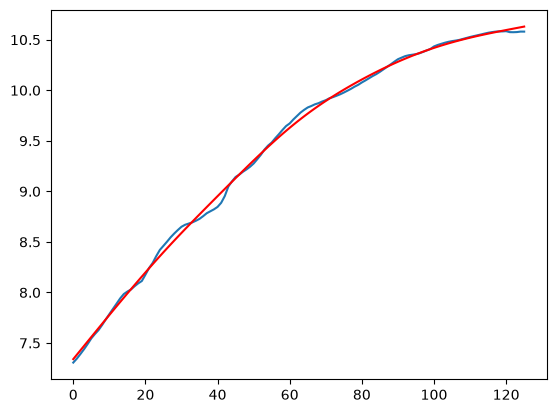

In [149]:
b_ridge = solve_ridge(Xfull, y, lambda_val = 10000) #lambda = 10000 seems to work well
#print(b_ridge)
plt.plot(y)
ridge_fitted = np.dot(Xfull, b_ridge)
plt.plot(ridge_fitted, color = 'red')
plt.show()

Here is the function for minimizing the LASSO objective function. Given $y_{n \times 1}$, $X_{n  \times m}$ and $\lambda$, this code solves the problem: 
\begin{align*}
    \text{Minimize} ~ \left[\|y - X \beta\|^2 + \lambda (|\beta_s| + \dots + |\beta_m|) \right]
\end{align*}
Here $s$ denotes `penalty_start` in the code (the penalty does not involve $\beta_j$ for $j < s$). 


In [150]:
def solve_lasso(X, y, lambda_val, penalty_start=2):
    n, p = X.shape
    
    # Define variable
    beta = cp.Variable(p)
    
    # Define objective
    loss = cp.sum_squares(X @ beta - y)
    reg = lambda_val * cp.norm1(beta[penalty_start:])
    objective = cp.Minimize(loss + reg)
    
    # Solve problem
    prob = cp.Problem(objective)
    #prob.solve(solver = cp.MOSEK, verbose = True)
    prob.solve(solver = cp.CLARABEL)
    #prob.solve(solver = cp.OSQP)    
    return beta.value


Below is the code for computing the ridge estimator with a fixed value of $\lambda$. We also plot the fitted values (these are the values $\hat{\mu}^{\text{lasso}}(\lambda) = X \hat{\beta}^{\text{lasso}}(\lambda)$) corresponding to the Ridge estimate. 

Play around with  different values of $\lambda$ and see how the estimator changes. 

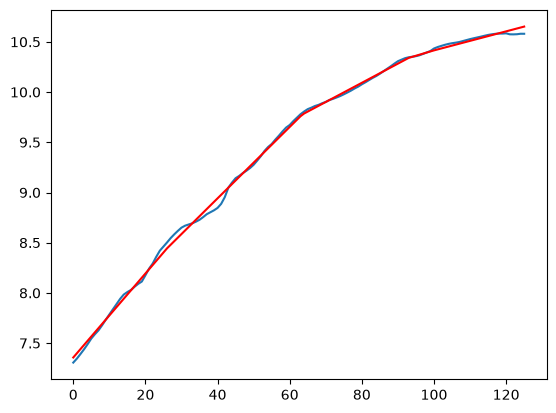

In [157]:
b_lasso = solve_lasso(Xfull, y, lambda_val = 10) #10 seems to work well
#print(b_lasso)
plt.plot(y)
lasso_fitted = np.dot(Xfull, b_lasso)
plt.plot(lasso_fitted, color = 'red')
plt.show()

The LASSO estimator is typically sparse. This can be checked by the code below where we only display the estimated coefficients which cross a threshold in absolute value. 

In [158]:
threshold = 1e-6
significant_idx = np.where(np.abs(b_lasso) > threshold)[0]
print(b_lasso[significant_idx])
# Or to see index-value pairs:
for idx in significant_idx:
    print(f"Index {idx}: {b_lasso[idx]}")

[ 7.35726177e+00  4.18060682e-02 -6.26223822e-03 -8.13745455e-03
 -8.31087995e-03 -7.35145027e-05 -8.35702636e-03 -1.18955749e-03]
Index 0: 7.357261773551294
Index 1: 0.041806068247922414
Index 27: -0.0062622382150850356
Index 64: -0.00813745454741311
Index 65: -0.008310879947738404
Index 93: -7.351450270850918e-05
Index 94: -0.008357026361513361
Index 101: -0.0011895574866604035


Below we plot both the ridge and LASSO fits.

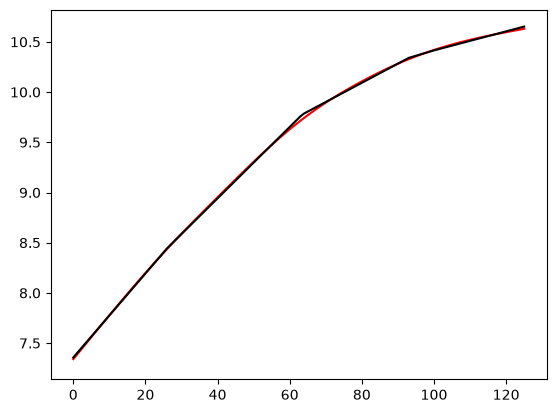

In [159]:
plt.plot(y, color = 'None')
ridge_fitted = np.dot(Xfull, b_ridge)
plt.plot(ridge_fitted, color = 'red')
lasso_fitted = np.dot(Xfull, b_lasso)
plt.plot(lasso_fitted, color = 'black')
plt.show()

The two fitted values seem quite similar.

## Fitting Smooth Trend Functions to Data

These models and the corresponding Ridge and LASSO estimators are useful for fitting trend functions to data. 

The following dataset (taken from [NOAA climate at a glance](https://www.ncei.noaa.gov/access/monitoring/climate-at-a-glance/statewide/time-series/1/tavg/1/0/1895-2026)) gives the average monthly temperatures for California from January 1895 to August 2026.

      year  month  value
0     1895      1   40.5
1     1895      2   46.0
2     1895      3   47.8
3     1895      4   53.7
4     1895      5   61.3
...    ...    ...    ...
1575  2026      4   56.1
1576  2026      5   64.0
1577  2026      6   72.4
1578  2026      7   77.6
1579  2026      8   79.0

[1580 rows x 3 columns]


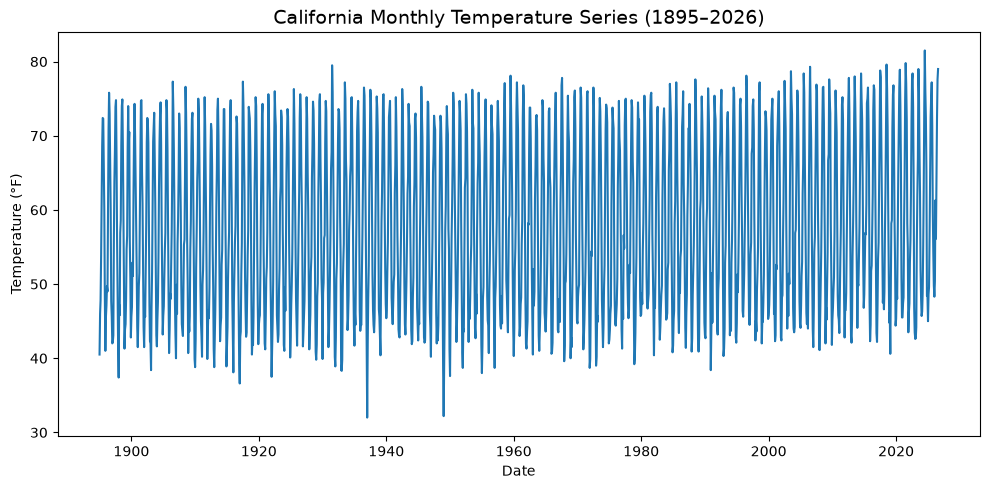

In [160]:
ca_temp = pd.read_csv('cag_CA_tavg.csv')
print(ca_temp)

# Create a datetime column for continuous time plotting
ca_temp['date'] = pd.to_datetime(
    ca_temp['year'].astype(str) + '-' + ca_temp['month'].astype(str).str.zfill(2) + '-01'
)

# Plot monthly temperatures
plt.figure(figsize=(10, 5))
plt.plot(ca_temp['date'], ca_temp['value'])
plt.title('California Monthly Temperature Series (1895–2026)', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Temperature (°F)')
plt.tight_layout()
plt.show()


Instead of the raw temperature averages, we shall work with temperature anomalies: for each calendar month (January, …, December) we compute California's average temperature for that calendar month over 1901–2000, and the anomaly for any month in the dataset is the recorded value minus this baseline for its own calendar month. An anomaly of $+1.2$ in July 2026 means that July 2026 was 1.2°C warmer than a typical twentieth-century July.

The reason for looking at anomalies is that the raw series is dominated by the seasonal cycle (about 20°C between January and July, roughly 95% of the variance), which is a known repeating pattern and not what we want to study. Subtracting each calendar month's baseline removes it and puts all months on the same footing, so what remains is month-to-month weather variability, which we treat as noise, plus any slow change in the climate, which is the trend we want to estimate.

   year  month  value       date   anomaly
0  1895      1   40.5 1895-01-01 -1.012222
1  1895      2   46.0 1895-02-01  0.369444
2  1895      3   47.8 1895-03-01 -0.541667
3  1895      4   53.7 1895-04-01 -0.175000
4  1895      5   61.3 1895-05-01  0.308333


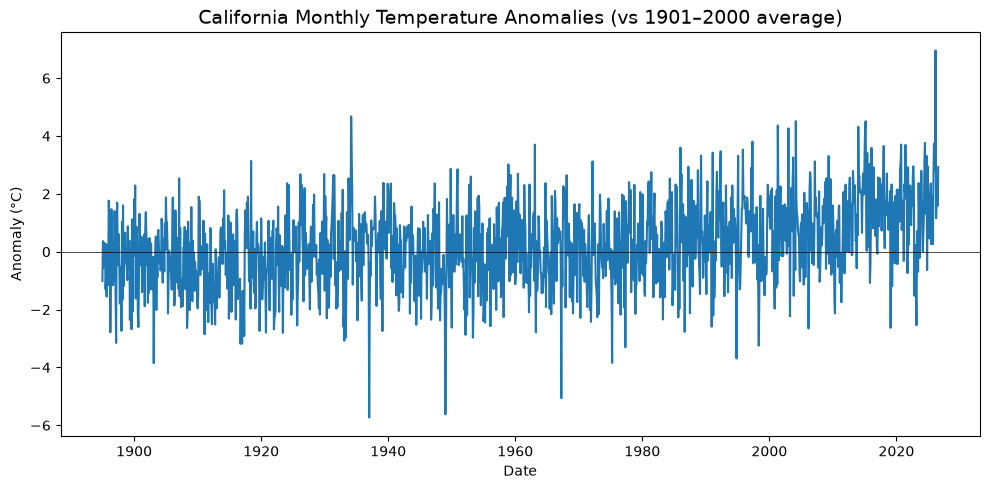

In [161]:
# Baseline: 1901-2000 mean for each calendar month
baseline = ca_temp[(ca_temp['year'] >= 1901) & (ca_temp['year'] <= 2000)].groupby('month')['value'].mean()

# Anomaly = value minus the baseline for its own calendar month (times 5/9 to convert the °F difference to °C)
ca_temp['anomaly'] = (ca_temp['value'] - ca_temp['month'].map(baseline)) * 5/9
print(ca_temp.head())

plt.figure(figsize=(10, 5))
plt.plot(ca_temp['date'], ca_temp['anomaly'])
plt.axhline(0, color='black', linewidth=0.5)
plt.title('California Monthly Temperature Anomalies (vs 1901–2000 average)', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Anomaly (°C)')
plt.tight_layout()
plt.show()

We shall now fit a trend function to this anomaly data, using our high-dimensional linear regression model. The first step is to create the X matrix. 

In [162]:
y = ca_temp['anomaly']
n = len(y) #both datasets have the same length, so the X matrix will be the same for both
x = np.arange(1, n+1)
Xfull = np.column_stack([np.ones(n), x-1])
for i in range(n-2):
    c = i+2
    xc = ((x > c).astype(float))*(x-c)
    Xfull = np.column_stack([Xfull, xc])
print(Xfull)

[[ 1.000e+00  0.000e+00 -0.000e+00 ... -0.000e+00 -0.000e+00 -0.000e+00]
 [ 1.000e+00  1.000e+00  0.000e+00 ... -0.000e+00 -0.000e+00 -0.000e+00]
 [ 1.000e+00  2.000e+00  1.000e+00 ... -0.000e+00 -0.000e+00 -0.000e+00]
 ...
 [ 1.000e+00  1.577e+03  1.576e+03 ...  1.000e+00  0.000e+00 -0.000e+00]
 [ 1.000e+00  1.578e+03  1.577e+03 ...  2.000e+00  1.000e+00  0.000e+00]
 [ 1.000e+00  1.579e+03  1.578e+03 ...  3.000e+00  2.000e+00  1.000e+00]]


The ridge regression estimate is computed below. Start with some standard choice of $\lambda$ (e.g., $\lambda = 1$) and then increase or decrease it by factors of 10 until you get a fit that is visually nice (smooth while capturing patterns in the data).

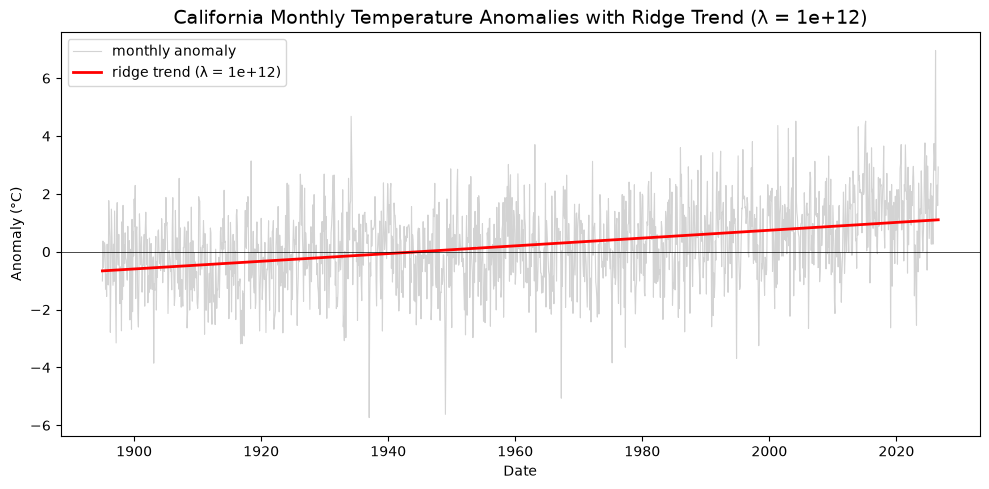

In [165]:
lambda_ridge = 1e12
b_ridge = solve_ridge(Xfull, y, lambda_val = lambda_ridge)
ridge_trend = np.dot(Xfull, b_ridge)
plt.figure(figsize=(10, 5))
plt.plot(ca_temp['date'], y, color='lightgray', linewidth=0.8, label='monthly anomaly')
plt.plot(ca_temp['date'], ridge_trend, color='red', linewidth=2, label=f'ridge trend (λ = {lambda_ridge:g})')
plt.axhline(0, color='black', linewidth=0.5)
plt.title(f'California Monthly Temperature Anomalies with Ridge Trend (λ = {lambda_ridge:g})', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Anomaly (°C)')
plt.legend()
plt.tight_layout()
plt.show()

We repeat the exercise with LASSO below. 

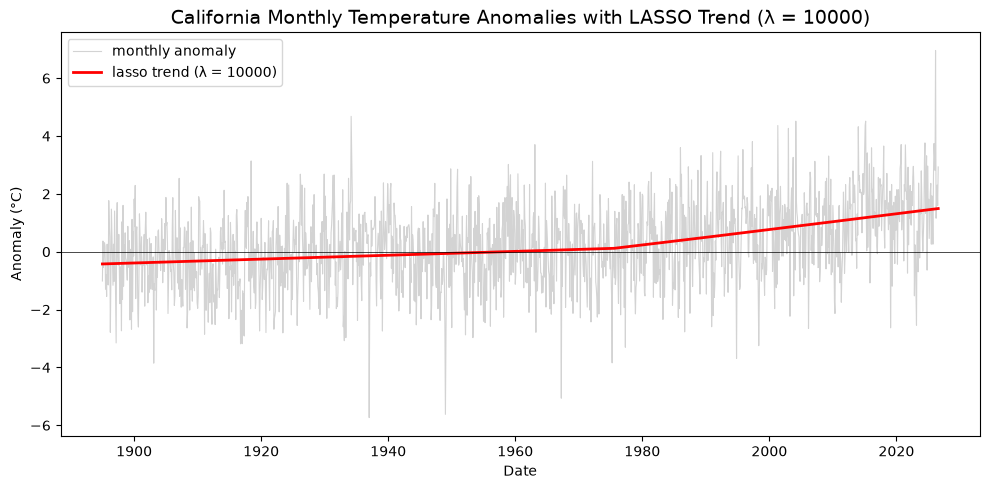

In [167]:
lambda_lasso = 1e4
b_lasso = solve_lasso(Xfull, y, lambda_val = lambda_lasso)
lasso_trend = np.dot(Xfull, b_lasso)
plt.figure(figsize=(10, 5))
plt.plot(ca_temp['date'], y, color='lightgray', linewidth=0.8, label='monthly anomaly')
plt.plot(ca_temp['date'], lasso_trend, color='red', linewidth=2, label=f'lasso trend (λ = {lambda_lasso:g})')
plt.axhline(0, color='black', linewidth=0.5)
plt.title(f'California Monthly Temperature Anomalies with LASSO Trend (λ = {lambda_lasso:g})', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Anomaly (°C)')
plt.legend()
plt.tight_layout()
plt.show()

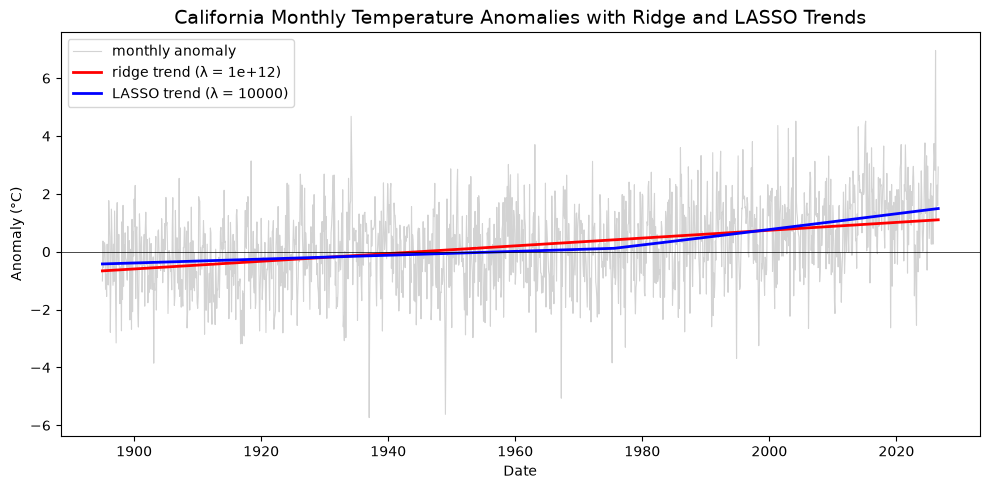

In [168]:
plt.figure(figsize=(10, 5))
plt.plot(ca_temp['date'], y, color='lightgray', linewidth=0.8, label='monthly anomaly')
plt.plot(ca_temp['date'], ridge_trend, color='red', linewidth=2, label=f'ridge trend (λ = {lambda_ridge:g})')
plt.plot(ca_temp['date'], lasso_trend, color='blue', linewidth=2, label=f'LASSO trend (λ = {lambda_lasso:g})')
plt.axhline(0, color='black', linewidth=0.5)
plt.title('California Monthly Temperature Anomalies with Ridge and LASSO Trends', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Anomaly (°C)')
plt.legend()
plt.tight_layout()
plt.show()

### Shrinkage and Sparsity

Let us compare the ridge regularized estimates of $\beta$ with the unregularized estimates (unregularized means $\lambda = 0$).

1.3816666666639175 -0.0004103633144908969
-1.012222222220763 -0.3492053868879078


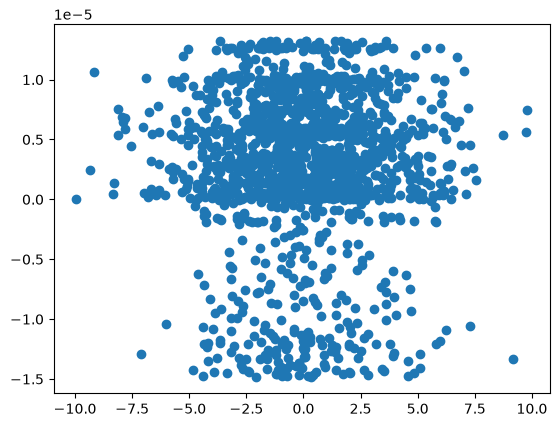

In [170]:
b_ridge_0 = solve_ridge(Xfull, y, lambda_val = 0)
b_ridge = solve_ridge(Xfull, y, lambda_val = 1e8)
plt.scatter(b_ridge_0[2:], b_ridge[2:])
print(b_ridge_0[1], b_ridge[1])
print(b_ridge_0[0], b_ridge[0])

Note that the $y$-axis above has a much tighter range compared to the $x$-axis. This illustrates the **shrinkage** aspect of ridge regression. It shrinks the unregularized estimates towards zero. 

1.3816666666667305 0.0005578030685411052
-1.0122222222222297 -0.4226540221392625


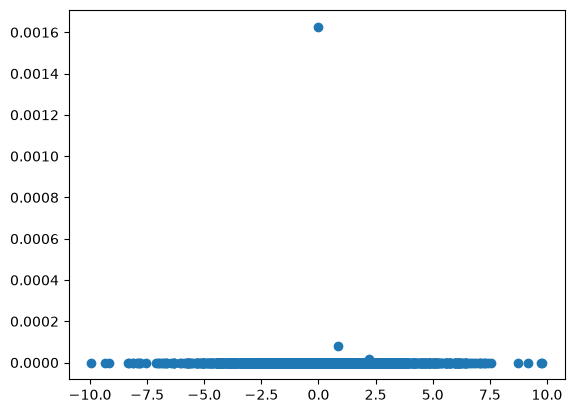

In [171]:
b_lasso_0 = solve_lasso(Xfull, y, lambda_val = 0)
b_lasso = solve_lasso(Xfull, y, lambda_val = lambda_lasso)
plt.scatter(b_lasso_0[2:], b_lasso[2:])
print(b_lasso_0[1], b_lasso[1])
print(b_lasso_0[0], b_lasso[0])

This plot clearly shows that the LASSO sets most coefficients exactly to zero. Compare this plot to the corresponding plot for the ridge estimator. This means that LASSO is setting most of the $\beta_j$'s to zero. This is referred to as **sparsity**. 

Ridge estimation results in shrinkage and LASSO estimation results in sparsity. 

## Cross-validation for picking $\lambda$

We use the following code for Cross-Validation for picking $\lambda$ in ridge regression. 

In [172]:
def ridge_cv(X, y, lambda_candidates):
    n = len(y)
    k = 5
    fold_size = n // k
    folds = []

    for i in range(k):
        start = i * fold_size
        end = (i + 1) * fold_size if i < k - 1 else n  # last fold includes remainder
        test_indices = np.arange(start, end)
        train_indices = np.concatenate([np.arange(0, start), np.arange(end, n)])
        folds.append((train_indices, test_indices))

    cv_errors = {lamb: 0 for lamb in lambda_candidates}

    for train_index, test_index in folds:
        X_train = X[train_index]
        X_test = X[test_index]
        y_train = y[train_index]
        y_test = y[test_index]

        for lamb in lambda_candidates:
            beta = solve_ridge(X_train, y_train, lambda_val=lamb)
            y_pred = np.dot(X_test, beta)
            squared_errors = (y_test - y_pred) ** 2
            cv_errors[lamb] += np.sum(squared_errors)

    for lamb in lambda_candidates:
        cv_errors[lamb] /= n

    best_lambda = min(cv_errors, key=cv_errors.get)
    return best_lambda, cv_errors


We need to select a set of candidate values for $\lambda$ for using the above CV function. For this candidate set of values, we take a coarse grid comprising of $10^a$ where $a$ is some subset of values in $\{-10, \dots, 10\}$. If the minimizing $\lambda$ appears at the endpoints of this grid, then the grid can be enlarged suitably. 

In [173]:
lambda_candidates = np.array([1e4, 1e5, 1e6, 1e7, 1e8, 1e9, 1e10])

best_lambda, cv_errors = ridge_cv(Xfull, y, lambda_candidates)
print(best_lambda)
for lamb, error in sorted(cv_errors.items()):
    print(f"Lambda = {lamb:.2f}, CV Error = {error:.6f}")


100000000.0
Lambda = 10000.00, CV Error = 21.523288
Lambda = 100000.00, CV Error = 3.183640
Lambda = 1000000.00, CV Error = 2.486844
Lambda = 10000000.00, CV Error = 1.948602
Lambda = 100000000.00, CV Error = 1.769726
Lambda = 1000000000.00, CV Error = 1.787015
Lambda = 10000000000.00, CV Error = 1.808539


Below is the version of this code for LASSO.

In [174]:
def lasso_cv(X, y, lambda_candidates):
    n = len(y)
    k = 5
    fold_size = n // k
    folds = []

    for i in range(k):
        start = i * fold_size
        end = (i + 1) * fold_size if i < k - 1 else n  # last fold includes remainder
        test_indices = np.arange(start, end)
        train_indices = np.concatenate([np.arange(0, start), np.arange(end, n)])
        folds.append((train_indices, test_indices))

    cv_errors = {lamb: 0 for lamb in lambda_candidates}

    for train_index, test_index in folds:
        X_train = X[train_index]
        X_test = X[test_index]
        y_train = y[train_index]
        y_test = y[test_index]

        for lamb in lambda_candidates:
            beta = solve_lasso(X_train, y_train, lambda_val=lamb)
            y_pred = np.dot(X_test, beta)
            squared_errors = (y_test - y_pred) ** 2
            cv_errors[lamb] += np.sum(squared_errors)

    for lamb in lambda_candidates:
        cv_errors[lamb] /= n

    best_lambda = min(cv_errors, key=cv_errors.get)
    return best_lambda, cv_errors


In [175]:
lambda_candidates = np.array([10, 100, 1000, 10000, 100000])
best_lambda, cv_errors = lasso_cv(Xfull, y, lambda_candidates)
print(best_lambda)
for lamb, error in sorted(cv_errors.items()):
    print(f"Lambda = {lamb:.2f}, CV Error = {error:.6f}")


1000
Lambda = 10.00, CV Error = 213.800543
Lambda = 100.00, CV Error = 11.690666
Lambda = 1000.00, CV Error = 1.785692
Lambda = 10000.00, CV Error = 1.800242
Lambda = 100000.00, CV Error = 1.847047


## Simulated Data

One application of this model is to compare the trend functions underlying two time series datasets, especially when the time series are sufficiently noisy that the underlying trend cannot be gleaned by directly looking at the data. We first demonstrate this in a simulation example, and then give a couple of real examples. 

I am simulating two time series datasets (of the same size $n = 1000$) using the code below. 

In [176]:
def smoothfun(x):
    ans = np.sin(15*x) + 3*np.exp(-(x ** 2)/2) + 0.5*((x - 0.5) ** 2) + 5 * np.log(x + 0.1) + 7
    return ans

n = 1000
xx = np.linspace(0, 1, n)
truth_1 = np.array([smoothfun(x) for x in xx])

sig_1 = 2
rng = np.random.default_rng(seed = 42)
errorsamples_1 = rng.normal(loc=0, scale = sig_1, size = n)
y_1 = truth_1 + errorsamples_1


xx = np.linspace(0, 1, n)
truth_2 = 0.8*truth_1

sig_2 = 3
errorsamples_2 = rng.normal(loc=0, scale = sig_2, size = n)
y_2 = truth_2 + errorsamples_2

Here are the two datasets plotted.

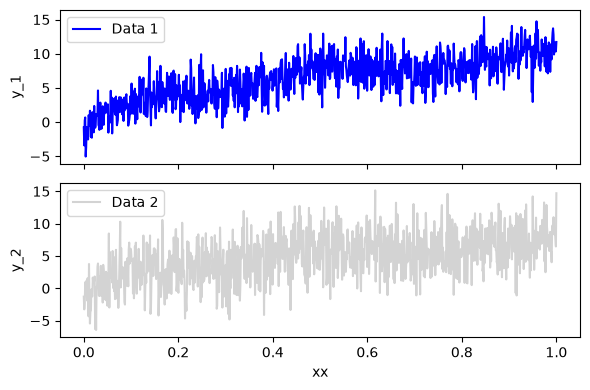

In [177]:
fig, axes = plt.subplots(2, 1, figsize=(6, 4), sharex=True)

# First panel
axes[0].plot(xx, y_1, label='Data 1', color='blue')
axes[0].legend()
axes[0].set_ylabel("y_1")

# Second panel
axes[1].plot(xx, y_2, label='Data 2', color='lightgray')
axes[1].legend()
axes[1].set_xlabel("xx")
axes[1].set_ylabel("y_2")

plt.tight_layout()
plt.show()


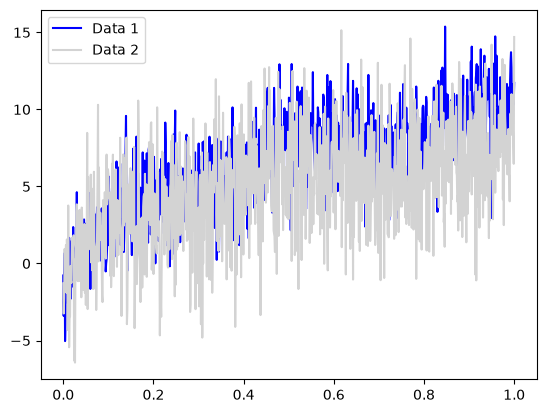

In [178]:
#Plotting both datasets together:
plt.plot(xx, y_1, label = 'Data 1', color = 'blue')
plt.plot(xx, y_2, label = 'Data 2', color = 'lightgray')
plt.legend()
plt.show()

Each of these datasets is generated by taking a smooth function, and adding noise to it. The smooth functions which generated the data are shown below. 

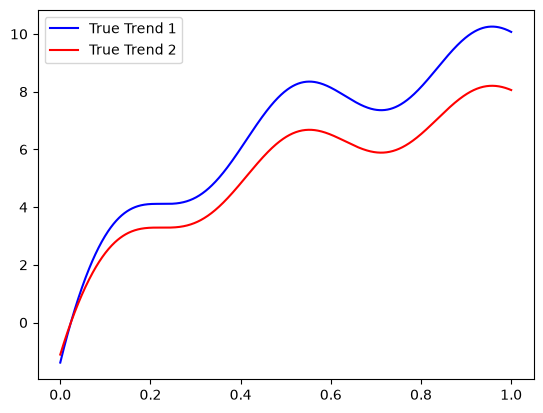

In [179]:
#True functions which generated the data:
plt.plot(xx, truth_1, label = 'True Trend 1', color = 'blue')
plt.plot(xx, truth_2, label = 'True Trend 2', color = 'red')
plt.legend()
plt.show()


These smooth functions (which generated the data) are clearly different. These differences are not easy to see however when we look at the raw data directly because of noise. We can use our trend estimates (based on ridge and lasso) to denoise the data so that they become comparable. 

In [180]:
y = y_1
n = len(y)
x = np.arange(1, n+1)
Xfull = np.column_stack([np.ones(n), x-1])
for i in range(n-2):
    c = i+2
    xc = ((x > c).astype(float))*(x-c)
    Xfull = np.column_stack([Xfull, xc])
print(Xfull)

[[  1.   0.  -0. ...  -0.  -0.  -0.]
 [  1.   1.   0. ...  -0.  -0.  -0.]
 [  1.   2.   1. ...  -0.  -0.  -0.]
 ...
 [  1. 997. 996. ...   1.   0.  -0.]
 [  1. 998. 997. ...   2.   1.   0.]
 [  1. 999. 998. ...   3.   2.   1.]]


In [181]:
lambda_candidates = np.array([1e1, 1e2, 1e3, 1e4, 1e5, 1e6, 1e7, 1e8])

best_lambda_1, cv_errors = ridge_cv(Xfull, y_1, lambda_candidates)
print(best_lambda_1)

best_lambda_2, cv_errors = ridge_cv(Xfull, y_2, lambda_candidates)
print(best_lambda_2)

1000000.0
1000000.0


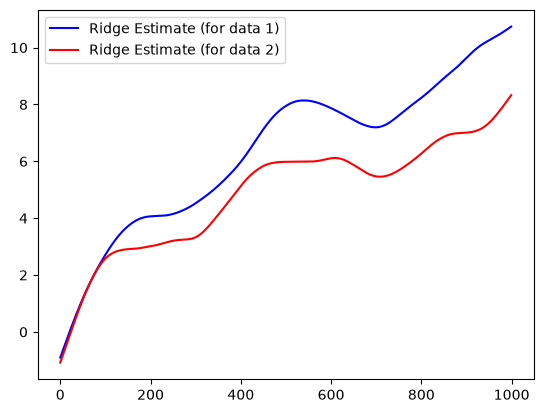

In [182]:
b_ridge_1 = solve_ridge(Xfull, y_1, lambda_val = best_lambda_1)
ridge_fitted_1 = np.dot(Xfull, b_ridge_1)

b_ridge_2 = solve_ridge(Xfull, y_2, lambda_val = best_lambda_2)
ridge_fitted_2 = np.dot(Xfull, b_ridge_2)

plt.plot(ridge_fitted_1, color = 'blue', label = 'Ridge Estimate (for data 1)')
plt.plot(ridge_fitted_2, color = 'red', label = "Ridge Estimate (for data 2)")
plt.legend()
plt.show()

In [183]:
lambda_candidates = np.array([1e1, 1e2, 1e3, 1e4])

best_lambda_1, cv_errors = lasso_cv(Xfull, y_1, lambda_candidates)
print(best_lambda_1)

best_lambda_2, cv_errors = lasso_cv(Xfull, y_2, lambda_candidates)
print(best_lambda_2)

1000.0
1000.0


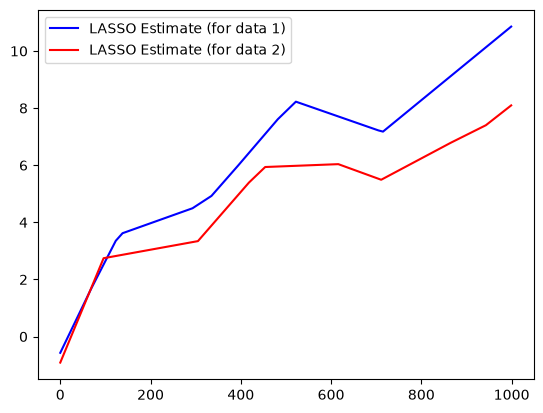

In [184]:
b_lasso_1 = solve_lasso(Xfull, y_1, lambda_val = best_lambda_1)
lasso_fitted_1 = np.dot(Xfull, b_lasso_1)

b_lasso_2 = solve_lasso(Xfull, y_2, lambda_val = best_lambda_2)
lasso_fitted_2 = np.dot(Xfull, b_lasso_2)

plt.plot(lasso_fitted_1, color = 'blue', label = 'LASSO Estimate (for data 1)')
plt.plot(lasso_fitted_2, color = 'red', label = "LASSO Estimate (for data 2)")
plt.legend()
plt.show()

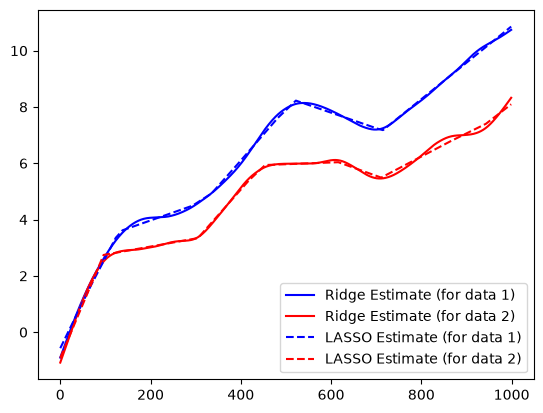

In [185]:
plt.plot(ridge_fitted_1, color = 'blue', label = 'Ridge Estimate (for data 1)')
plt.plot(ridge_fitted_2, color = 'red', label = "Ridge Estimate (for data 2)")
plt.plot(lasso_fitted_1, color = 'blue', linestyle = '--', label = 'LASSO Estimate (for data 1)')
plt.plot(lasso_fitted_2, color = 'red', linestyle = '--', label = "LASSO Estimate (for data 2)")
plt.legend()
plt.show()

## Anomalies: CA vs AL

As a real data example, we compare the temperature anomalies data between two states (CA and AL). 

      year  month  value
0     1895      1   43.1
1     1895      2   37.4
2     1895      3   54.5
3     1895      4   63.4
4     1895      5   69.5
...    ...    ...    ...
1575  2026      4   67.0
1576  2026      5   70.5
1577  2026      6   77.8
1578  2026      7   81.7
1579  2026      8   81.7

[1580 rows x 3 columns]


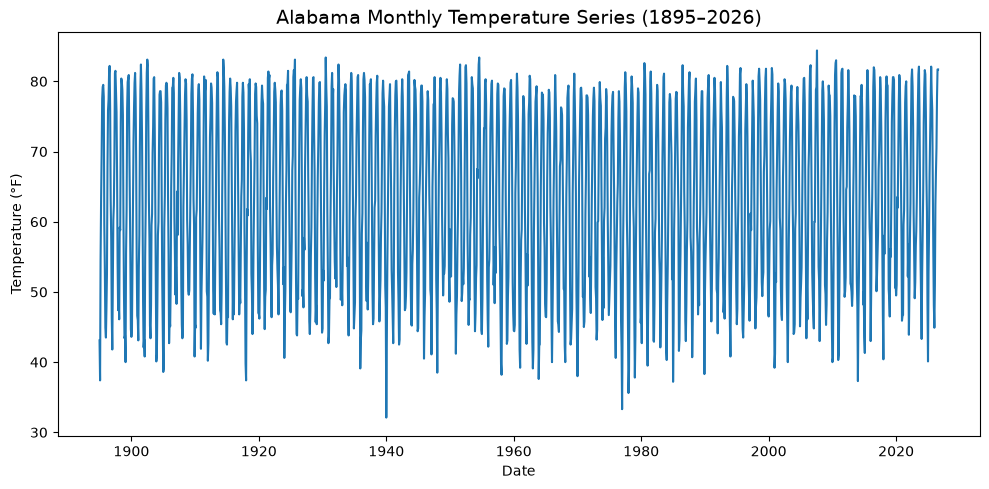

In [186]:
al_temp = pd.read_csv('cag_AL_tavg.csv')
print(al_temp)

# Create a datetime column for continuous time plotting
al_temp['date'] = pd.to_datetime(
    al_temp['year'].astype(str) + '-' + al_temp['month'].astype(str).str.zfill(2) + '-01'
)

# Plot monthly temperatures
plt.figure(figsize=(10, 5))
plt.plot(al_temp['date'], al_temp['value'])
plt.title('Alabama Monthly Temperature Series (1895–2026)', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Temperature (°F)')
plt.tight_layout()
plt.show()


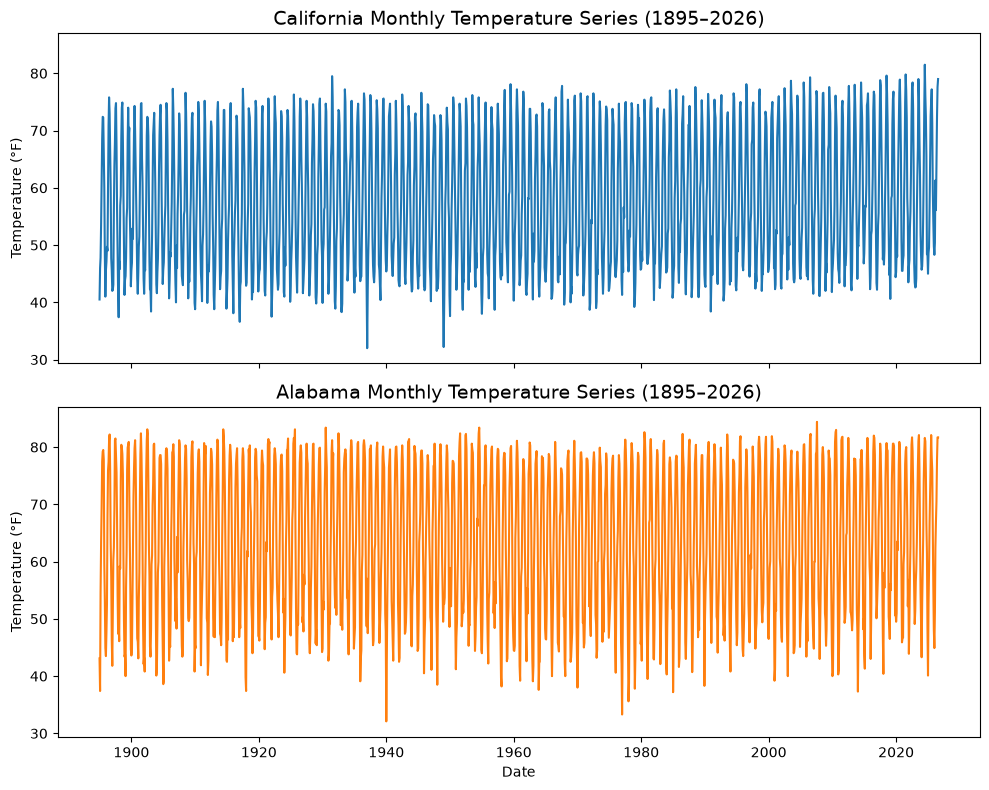

In [187]:
fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True, sharey=True)

axes[0].plot(ca_temp['date'], ca_temp['value'])
axes[0].set_title('California Monthly Temperature Series (1895–2026)', fontsize=14)
axes[0].set_ylabel('Temperature (°F)')

axes[1].plot(al_temp['date'], al_temp['value'], color='C1')
axes[1].set_title('Alabama Monthly Temperature Series (1895–2026)', fontsize=14)
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Temperature (°F)')

plt.tight_layout()
plt.show()

Both plots in one figure. 

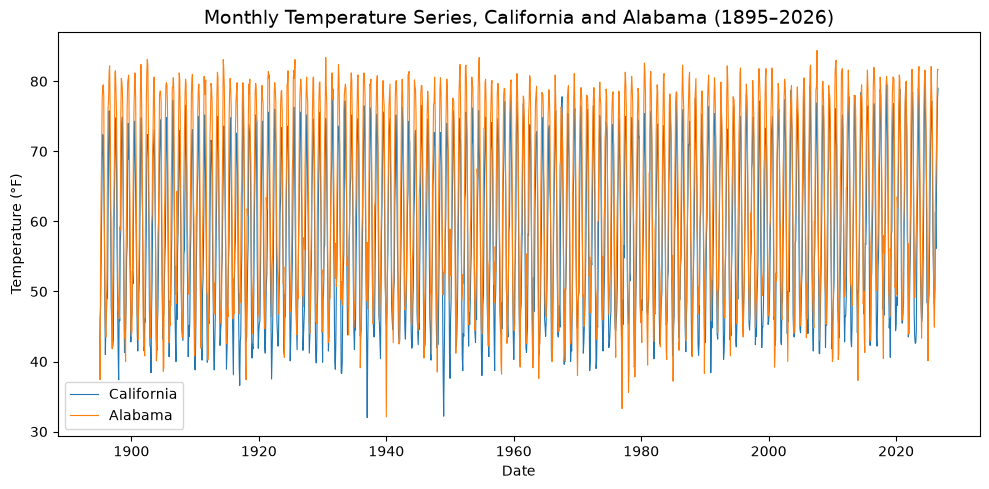

In [188]:
plt.figure(figsize=(10, 5))
plt.plot(ca_temp['date'], ca_temp['value'], color='C0', linewidth=0.8, label='California')
plt.plot(al_temp['date'], al_temp['value'], color='C1', linewidth=0.8, label='Alabama')
plt.title('Monthly Temperature Series, California and Alabama (1895–2026)', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Temperature (°F)')
plt.legend()
plt.tight_layout()
plt.show()

We focus  on anomalies as opposed to the raw temperatures. 

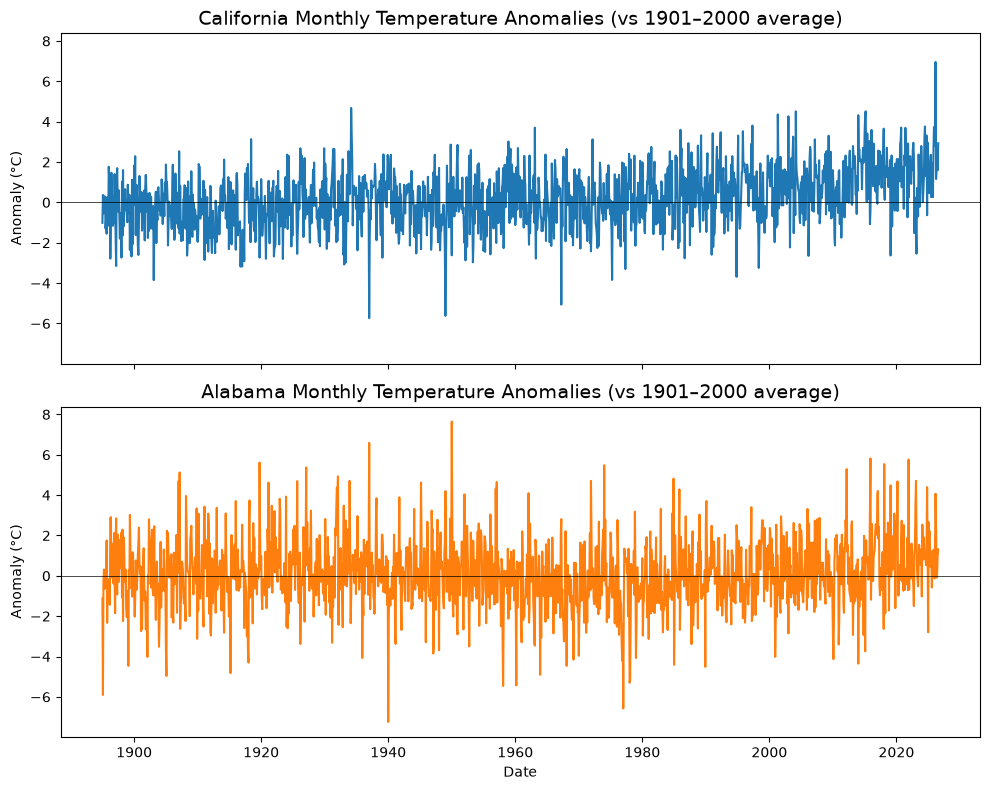

In [189]:
# Alabama anomalies, same recipe as for California
baseline_al = al_temp[(al_temp['year'] >= 1901) & (al_temp['year'] <= 2000)].groupby('month')['value'].mean()
al_temp['anomaly'] = (al_temp['value'] - al_temp['month'].map(baseline_al)) * 5/9

fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True, sharey=True)

axes[0].plot(ca_temp['date'], ca_temp['anomaly'])
axes[0].axhline(0, color='black', linewidth=0.5)
axes[0].set_title('California Monthly Temperature Anomalies (vs 1901–2000 average)', fontsize=14)
axes[0].set_ylabel('Anomaly (°C)')

axes[1].plot(al_temp['date'], al_temp['anomaly'], color='C1')
axes[1].axhline(0, color='black', linewidth=0.5)
axes[1].set_title('Alabama Monthly Temperature Anomalies (vs 1901–2000 average)', fontsize=14)
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Anomaly (°C)')

plt.tight_layout()
plt.show()

Here are both the anomalies plotted in one plot. 

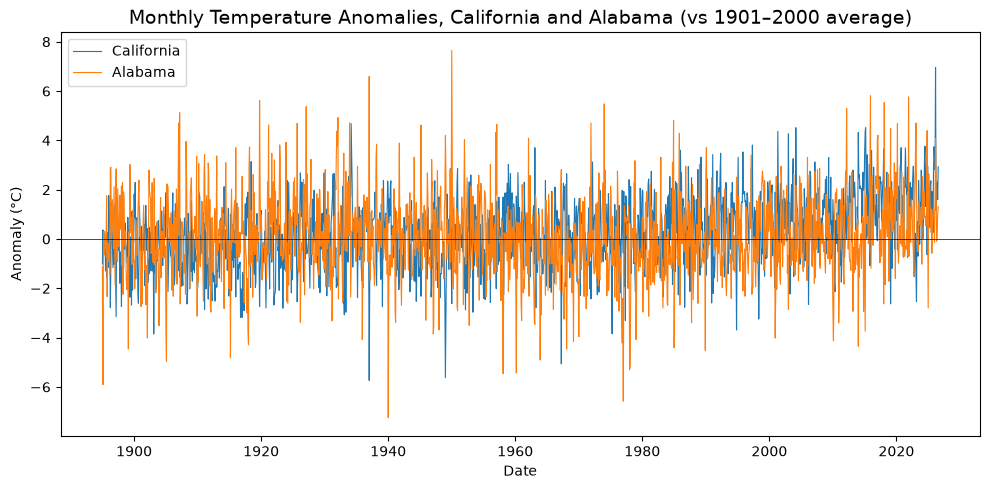

In [190]:
plt.figure(figsize=(10, 5))
plt.plot(ca_temp['date'], ca_temp['anomaly'], color='C0', linewidth=0.8, label='California')
plt.plot(al_temp['date'], al_temp['anomaly'], color='C1', linewidth=0.8, label='Alabama')
plt.axhline(0, color='black', linewidth=0.5)
plt.title('Monthly Temperature Anomalies, California and Alabama (vs 1901–2000 average)', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Anomaly (°C)')
plt.legend()
plt.tight_layout()
plt.show()

It is difficult to compare them directly. Here the trend functions give a useful comparison. 

In [191]:
y_1 = ca_temp['anomaly']
y_2 = al_temp['anomaly']
n = len(y_1) #both datasets have the same length
x = np.arange(1, n+1)
Xfull = np.column_stack([np.ones(n), x-1])
for i in range(n-2):
    c = i+2
    xc = ((x > c).astype(float))*(x-c)
    Xfull = np.column_stack([Xfull, xc])
print(Xfull)

[[ 1.000e+00  0.000e+00 -0.000e+00 ... -0.000e+00 -0.000e+00 -0.000e+00]
 [ 1.000e+00  1.000e+00  0.000e+00 ... -0.000e+00 -0.000e+00 -0.000e+00]
 [ 1.000e+00  2.000e+00  1.000e+00 ... -0.000e+00 -0.000e+00 -0.000e+00]
 ...
 [ 1.000e+00  1.577e+03  1.576e+03 ...  1.000e+00  0.000e+00 -0.000e+00]
 [ 1.000e+00  1.578e+03  1.577e+03 ...  2.000e+00  1.000e+00  0.000e+00]
 [ 1.000e+00  1.579e+03  1.578e+03 ...  3.000e+00  2.000e+00  1.000e+00]]


In [192]:
lambda_candidates = np.array([1e7, 1e8, 1e9, 1e10])

best_lambda_1, cv_errors = ridge_cv(Xfull, y_1, lambda_candidates)
print(best_lambda_1)

best_lambda_2, cv_errors = ridge_cv(Xfull, y_2, lambda_candidates)
print(best_lambda_2)

100000000.0
100000000.0


In [193]:
b_ridge_1 = solve_ridge(Xfull, y_1, lambda_val = best_lambda_1)
ridge_fitted_1 = np.dot(Xfull, b_ridge_1)

b_ridge_2 = solve_ridge(Xfull, y_2, lambda_val = best_lambda_2)
ridge_fitted_2 = np.dot(Xfull, b_ridge_2)

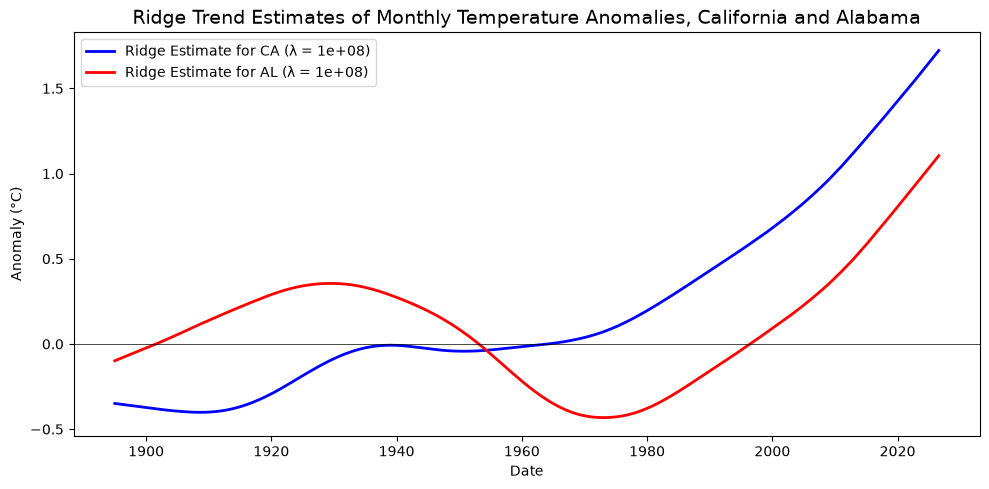

In [194]:
plt.figure(figsize=(10, 5))
plt.plot(ca_temp['date'], ridge_fitted_1, color='blue', linewidth=2, label=f'Ridge Estimate for CA (λ = {best_lambda_1:g})')
plt.plot(al_temp['date'], ridge_fitted_2, color='red', linewidth=2, label=f'Ridge Estimate for AL (λ = {best_lambda_2:g})')
plt.axhline(0, color='black', linewidth=0.5)
plt.title('Ridge Trend Estimates of Monthly Temperature Anomalies, California and Alabama', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Anomaly (°C)')
plt.legend()
plt.tight_layout()
plt.show()

California has warmed somewhat consistently since the 60s. But Alabama actually cooled down for a period before steady warming. 

In [195]:
lambda_candidates = np.array([1e2, 1e3, 1e4])

best_lambda_1, cv_errors = lasso_cv(Xfull, y_1, lambda_candidates)
print(best_lambda_1)

best_lambda_2, cv_errors = lasso_cv(Xfull, y_2, lambda_candidates)
print(best_lambda_2)

1000.0
1000.0


In [196]:
b_lasso_1 = solve_lasso(Xfull, y_1, lambda_val = best_lambda_1)
lasso_fitted_1 = np.dot(Xfull, b_lasso_1)

b_lasso_2 = solve_lasso(Xfull, y_2, lambda_val = best_lambda_2)
lasso_fitted_2 = np.dot(Xfull, b_lasso_2)

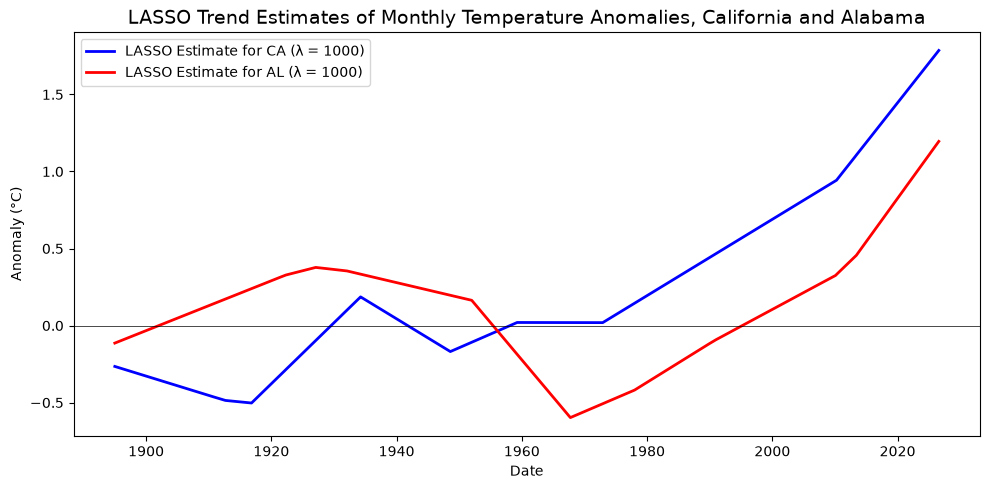

In [197]:
plt.figure(figsize=(10, 5))
plt.plot(ca_temp['date'], lasso_fitted_1, color='blue', linewidth=2, label=f'LASSO Estimate for CA (λ = {best_lambda_1:g})')
plt.plot(al_temp['date'], lasso_fitted_2, color='red', linewidth=2, label=f'LASSO Estimate for AL (λ = {best_lambda_2:g})')
plt.axhline(0, color='black', linewidth=0.5)
plt.title('LASSO Trend Estimates of Monthly Temperature Anomalies, California and Alabama', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Anomaly (°C)')
plt.legend()
plt.tight_layout()
plt.show()

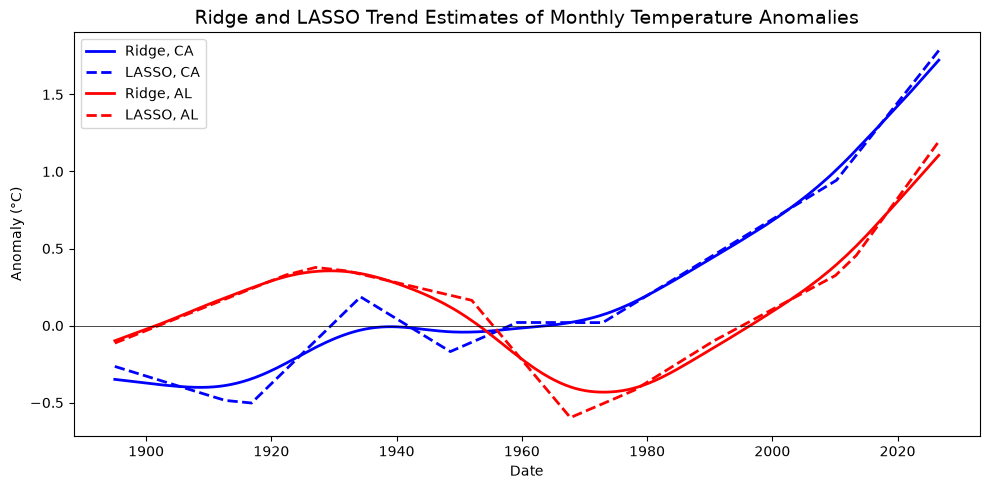

In [198]:
plt.figure(figsize=(10, 5))
plt.plot(ca_temp['date'], ridge_fitted_1, color='blue', linewidth=2, label='Ridge, CA')
plt.plot(ca_temp['date'], lasso_fitted_1, color='blue', linewidth=2, linestyle='--', label='LASSO, CA')
plt.plot(al_temp['date'], ridge_fitted_2, color='red', linewidth=2, label='Ridge, AL')
plt.plot(al_temp['date'], lasso_fitted_2, color='red', linewidth=2, linestyle='--', label='LASSO, AL')
plt.axhline(0, color='black', linewidth=0.5)
plt.title('Ridge and LASSO Trend Estimates of Monthly Temperature Anomalies', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Anomaly (°C)')
plt.legend()
plt.tight_layout()
plt.show()

In this example, ridge regularization seems to give a smoother plot that is nicer to look at, compared to LASSO regularization. 

## CA anomalies: night vs day

As another example, let us look at the maximum daily temperatures (day) and minimum daily temperatures (night)

In [199]:
ca_temp_day = pd.read_csv('cag_CA_tmax.csv')
print(ca_temp_day)

# Create a datetime column for continuous time plotting
ca_temp_day['date'] = pd.to_datetime(
    ca_temp_day['year'].astype(str) + '-' + al_temp['month'].astype(str).str.zfill(2) + '-01'
)

ca_temp_night = pd.read_csv('cag_CA_tmin.csv')
print(ca_temp_night)

# Create a datetime column for continuous time plotting
ca_temp_night['date'] = pd.to_datetime(
    ca_temp_night['year'].astype(str) + '-' + al_temp['month'].astype(str).str.zfill(2) + '-01'
)

      year  month  value
0     1895      1   47.4
1     1895      2   56.1
2     1895      3   58.2
3     1895      4   65.6
4     1895      5   74.3
...    ...    ...    ...
1575  2026      4   68.4
1576  2026      5   77.4
1577  2026      6   86.7
1578  2026      7   92.1
1579  2026      8   93.6

[1580 rows x 3 columns]
      year  month  value
0     1895      1   33.6
1     1895      2   36.0
2     1895      3   37.4
3     1895      4   41.8
4     1895      5   48.3
...    ...    ...    ...
1575  2026      4   43.8
1576  2026      5   50.6
1577  2026      6   58.0
1578  2026      7   63.1
1579  2026      8   64.5

[1580 rows x 3 columns]


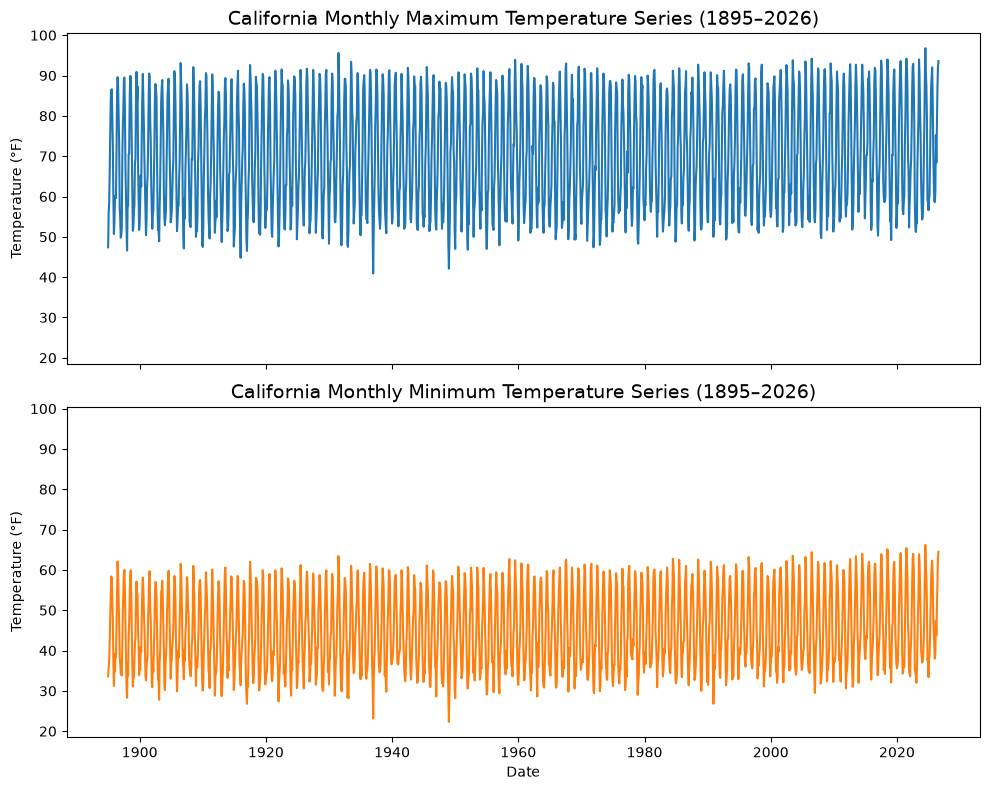

In [200]:
fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True, sharey=True)

axes[0].plot(ca_temp_day['date'], ca_temp_day['value'])
axes[0].set_title('California Monthly Maximum Temperature Series (1895–2026)', fontsize=14)
axes[0].set_ylabel('Temperature (°F)')

axes[1].plot(ca_temp_night['date'], ca_temp_night['value'], color='C1')
axes[1].set_title('California Monthly Minimum Temperature Series (1895–2026)', fontsize=14)
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Temperature (°F)')

plt.tight_layout()
plt.show()

In [201]:
baseline_day = ca_temp_day[(ca_temp_day['year'] >= 1901) & (ca_temp_day['year'] <= 2000)].groupby('month')['value'].mean()
ca_temp_day['anomaly'] = (ca_temp_day['value'] - ca_temp_day['month'].map(baseline_day)) * 5/9

baseline_night = ca_temp_night[(ca_temp_night['year'] >= 1901) & (ca_temp_night['year'] <= 2000)].groupby('month')['value'].mean()
ca_temp_night['anomaly'] = (ca_temp_night['value'] - ca_temp_night['month'].map(baseline_night)) * 5/9

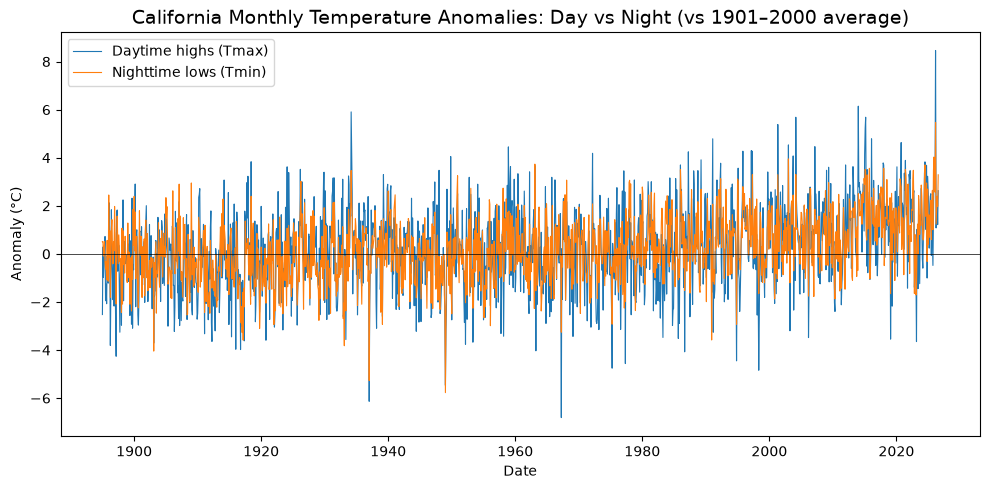

In [202]:
plt.figure(figsize=(10, 5))
plt.plot(ca_temp_day['date'], ca_temp_day['anomaly'], color='C0', linewidth=0.8, label='Daytime highs (Tmax)')
plt.plot(ca_temp_night['date'], ca_temp_night['anomaly'], color='C1', linewidth=0.8, label='Nighttime lows (Tmin)')
plt.axhline(0, color='black', linewidth=0.5)
plt.title('California Monthly Temperature Anomalies: Day vs Night (vs 1901–2000 average)', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Anomaly (°C)')
plt.legend()
plt.tight_layout()
plt.show()

It is difficult to understand differences between the two time series from this plot. We can again fit the model (via ridge or lasso regularization), and then plot the estimated trend functions. 

In [203]:
y_1 = ca_temp_day['anomaly']
y_2 = ca_temp_night['anomaly']
n = len(y_1) #both datasets have the same length
x = np.arange(1, n+1)
Xfull = np.column_stack([np.ones(n), x-1])
for i in range(n-2):
    c = i+2
    xc = ((x > c).astype(float))*(x-c)
    Xfull = np.column_stack([Xfull, xc])
print(Xfull)

[[ 1.000e+00  0.000e+00 -0.000e+00 ... -0.000e+00 -0.000e+00 -0.000e+00]
 [ 1.000e+00  1.000e+00  0.000e+00 ... -0.000e+00 -0.000e+00 -0.000e+00]
 [ 1.000e+00  2.000e+00  1.000e+00 ... -0.000e+00 -0.000e+00 -0.000e+00]
 ...
 [ 1.000e+00  1.577e+03  1.576e+03 ...  1.000e+00  0.000e+00 -0.000e+00]
 [ 1.000e+00  1.578e+03  1.577e+03 ...  2.000e+00  1.000e+00  0.000e+00]
 [ 1.000e+00  1.579e+03  1.578e+03 ...  3.000e+00  2.000e+00  1.000e+00]]


In [204]:
lambda_candidates = np.array([1e7, 1e8, 1e9, 1e10])

best_lambda_1, cv_errors = ridge_cv(Xfull, y_1, lambda_candidates)
print(best_lambda_1)

best_lambda_2, cv_errors = ridge_cv(Xfull, y_2, lambda_candidates)
print(best_lambda_2)

100000000.0
1000000000.0


In [205]:
b_ridge_1 = solve_ridge(Xfull, y_1, lambda_val = best_lambda_1)
ridge_fitted_1 = np.dot(Xfull, b_ridge_1)

b_ridge_2 = solve_ridge(Xfull, y_2, lambda_val = best_lambda_2)
ridge_fitted_2 = np.dot(Xfull, b_ridge_2)

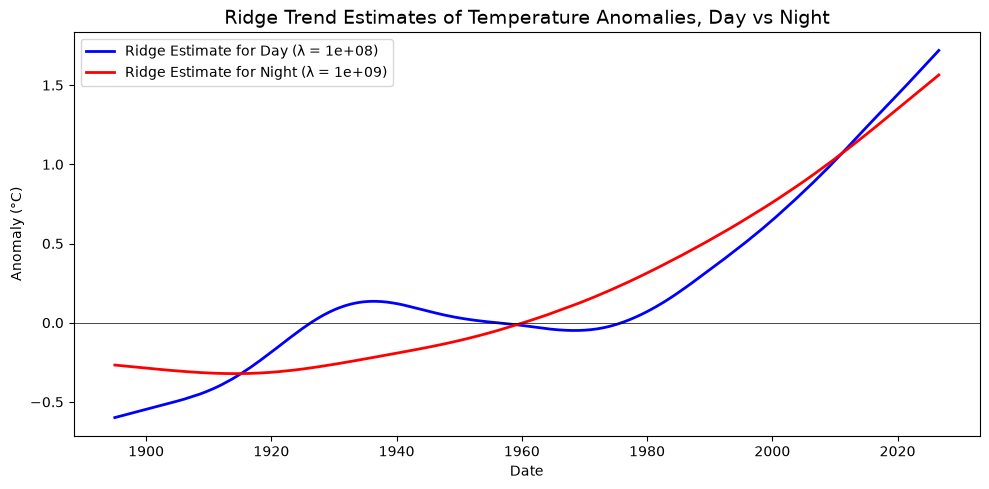

In [206]:
plt.figure(figsize=(10, 5))
plt.plot(ca_temp_day['date'], ridge_fitted_1, color='blue', linewidth=2, label=f'Ridge Estimate for Day (λ = {best_lambda_1:g})')
plt.plot(ca_temp_night['date'], ridge_fitted_2, color='red', linewidth=2, label=f'Ridge Estimate for Night (λ = {best_lambda_2:g})')
plt.axhline(0, color='black', linewidth=0.5)
plt.title('Ridge Trend Estimates of Temperature Anomalies, Day vs Night', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Anomaly (°C)')
plt.legend()
plt.tight_layout()
plt.show()

So nights started warming earlier than days, but now days have warmed up more. 

In [207]:
lambda_candidates = np.array([1e2, 1e3, 1e4])

best_lambda_1, cv_errors = lasso_cv(Xfull, y_1, lambda_candidates)
print(best_lambda_1)

best_lambda_2, cv_errors = lasso_cv(Xfull, y_2, lambda_candidates)
print(best_lambda_2)

1000.0
10000.0


In [208]:
b_lasso_1 = solve_lasso(Xfull, y_1, lambda_val = best_lambda_1)
lasso_fitted_1 = np.dot(Xfull, b_lasso_1)

b_lasso_2 = solve_lasso(Xfull, y_2, lambda_val = best_lambda_2)
lasso_fitted_2 = np.dot(Xfull, b_lasso_2)

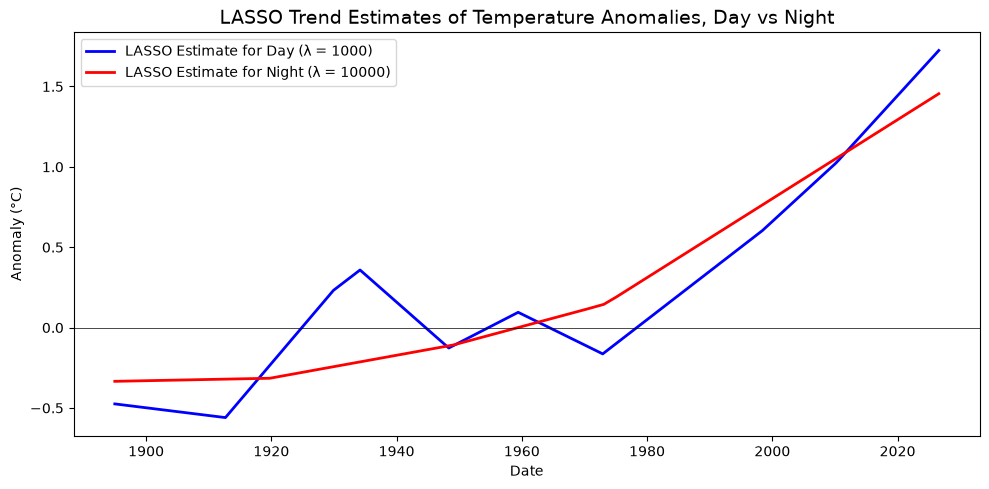

In [209]:
plt.figure(figsize=(10, 5))
plt.plot(ca_temp_day['date'], lasso_fitted_1, color='blue', linewidth=2, label=f'LASSO Estimate for Day (λ = {best_lambda_1:g})')
plt.plot(ca_temp_night['date'], lasso_fitted_2, color='red', linewidth=2, label=f'LASSO Estimate for Night (λ = {best_lambda_2:g})')
plt.axhline(0, color='black', linewidth=0.5)
plt.title('LASSO Trend Estimates of Temperature Anomalies, Day vs Night', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Anomaly (°C)')
plt.legend()
plt.tight_layout()
plt.show()

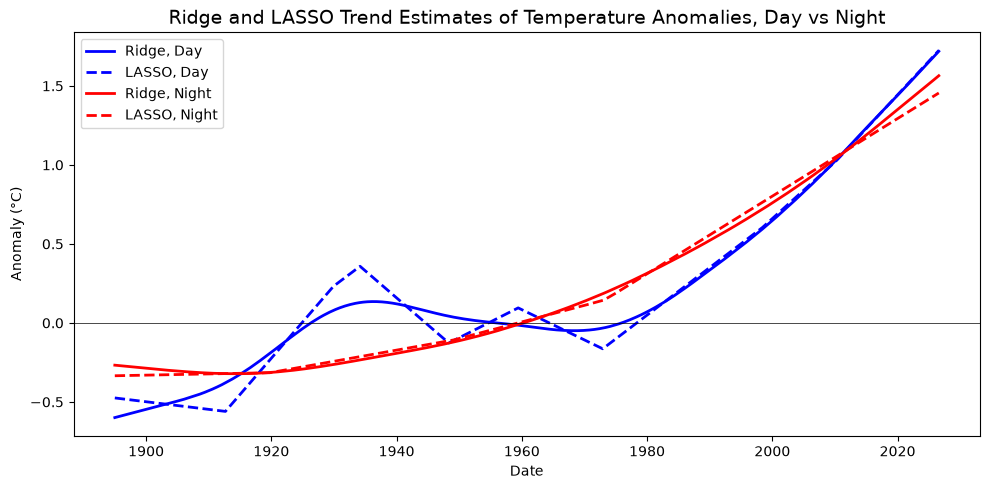

In [210]:
plt.figure(figsize=(10, 5))
plt.plot(ca_temp_day['date'], ridge_fitted_1, color='blue', linewidth=2, label='Ridge, Day')
plt.plot(ca_temp_day['date'], lasso_fitted_1, color='blue', linewidth=2, linestyle='--', label='LASSO, Day')
plt.plot(ca_temp_night['date'], ridge_fitted_2, color='red', linewidth=2, label='Ridge, Night')
plt.plot(ca_temp_night['date'], lasso_fitted_2, color='red', linewidth=2, linestyle='--', label='LASSO, Night')
plt.axhline(0, color='black', linewidth=0.5)
plt.title('Ridge and LASSO Trend Estimates of Temperature Anomalies, Day vs Night', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Anomaly (°C)')
plt.legend()
plt.tight_layout()
plt.show()